# Week 5 Lab 3: Logistic Regression

## Foreword
This lab introduces **Logistic Regression** for binary classification. Unlike Linear Regression (which predicts numbers), Logistic Regression predicts **categories** (Yes/No, 0/1).

You will classify house rental decisions based on Price and Area features, learning:
- Data normalization with `StandardScaler`
- The sigmoid function for probability output
- The difference between `predict()` and `predict_proba()`


## Part 1: Logistic Regression
We use a custom dataset representing House Rent vs. Area size. We will predict if a room is worth renting (1 = Yes, 0 = No).

### Step 1: Import Dependencies
We need `StandardScaler` to normalize our data (make the scale of 'Area' and 'Price' comparable) and `LogisticRegression` for the model.

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

### Step 2: Define and Preprocess Data
We manually define the dataset `X` (Rent, Area) and labels `y` (Decision).
Then, we use `fit_transform` to standardize the data (mean=0, variance=1).

In [2]:
X = [[2200,15],[2750,20],[5000,40],[4000,20],[3300,20],[2000,10],[2500,12],[12000,80],
     [2880,10],[2300,15],[1500,10],[3000,8],[2000,14],[2000,10],[2150,8],[3400,20],
     [5000,20],[4000,10],[3300,15],[2000,12],[2500,14],[10000,100],[3150,10],
     [2950,15],[1500,5],[3000,18],[8000,12],[2220,14],[6000,100],[3050,10]]

y = [1,1,0,0,1,1,1,1,0,1,1,0,1,1,0,1,0,0,0,1,1,1,0,1,0,1,0,1,1,0]

ss = StandardScaler()
X_train = ss.fit_transform(X)
print("Standardized Data (First 5):\n", X_train[:5])

Standardized Data (First 5):
 [[-0.60583897 -0.29313058]
 [-0.37682768 -0.09050576]
 [ 0.56003671  0.71999355]
 [ 0.14365254 -0.09050576]
 [-0.14781638 -0.09050576]]


### Step 3: Train the Model
We fit the Logistic Regression model to our standardized training data.

In [3]:
# Exercise 1: Initialize Logistic Regression
# TODO: Create the LogisticRegression model
model = None

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

<details>
<summary><strong>Click for Solution</strong></summary>

```python
lr = LogisticRegression()
lr.fit(X_train, y)
```
</details>

### Step 4: Make Predictions
We test the model with a new sample (Rent=2000, Area=8).
**Note**: We must `transform` the test data using the *same scaler* we used for training before making a prediction.

In [4]:
testX = [[2000,8]]
X_test = ss.transform(testX)
print("Value to be predicted: ", X_test)

label = lr.predict(X_test)
prob = lr.predict_proba(X_test)

print(f"Predicted Label: {label[0]} (1=Yes, 0=No)")
print(f"Probabilities (No / Yes): {prob}")

Value to be predicted:  [[-0.68911581 -0.57680534]]
Predicted Label: 1 (1=Yes, 0=No)
Probabilities (No / Yes): [[0.41882379 0.58117621]]


## Part 2: Decision Trees
We use the `tennis.txt` dataset to build a tree that predicts whether to play tennis based on weather.

### Step 1: Import Dependencies
We need `pandas` for data handling and `tree` from `sklearn`.

In [ ]:
pip install pandas

In [7]:
import pandas as pd
from sklearn import tree
import numpy as np

### Step 2: Load and Encode Data
Decision Trees require numerical input. The Tennis dataset uses text (Sunny, Hot, etc.).
We convert these categorical strings into numbers (Codes) using `pd.Categorical.codes`.

In [8]:
def data2vectoc(data):
    # Convert all columns except the last one (if we wanted to be selective, but here we do all)
    # Actually, we need to map valid strings to consistent numbers.
    # For simplicity in this lab, `cat.codes` works, but remember mappings for prediction!
    for col in data.columns:
        data[col] = pd.Categorical(data[col]).codes
    return data

data = pd.read_csv("tennis.txt", sep='\t', header=None)
data.columns = ['Outlook', 'Temp', 'Humidity', 'Wind', 'Play']

print("Original Data Head:\n", data.head())

# Vectorize
data_encoded = data2vectoc(data.copy())
print("\nEncoded Data Head:\n", data_encoded.head())

Original Data Head:
     Outlook  Temp Humidity    Wind Play
0     Sunny   Hot     High    Weak   No
1     Sunny   Hot     High  Strong   No
2  Overcast   Hot     High    Weak  Yes
3      Rain  Mild     High    Weak  Yes
4      Rain  Cool   Normal    Weak  Yes

Encoded Data Head:
    Outlook  Temp  Humidity  Wind  Play
0        2     1         0     1     0
1        2     1         0     0     0
2        0     1         0     1     1
3        1     2         0     1     1
4        1     0         1     1     1


### Step 3: Train the Tree
We split the data into Features (First 4 columns) and Labels (Last column).
We use `criterion='entropy'` because we want to split based on Information Gain.

In [9]:
# Exercise 2: Initialize Decision Tree
# TODO: Create DecisionTreeClassifier with max_depth=3
tree_model = None

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

<details>
<summary><strong>Click for Solution</strong></summary>

```python
X_train = data_encoded.iloc[:, :-1]
y_train = data_encoded.iloc[:, -1]

clf = tree.DecisionTreeClassifier(criterion="entropy")
clf.fit(X_train, y_train)
```
</details>

### Step 4: Visualize the Tree
We can plot the decision tree structure directly in the notebook.

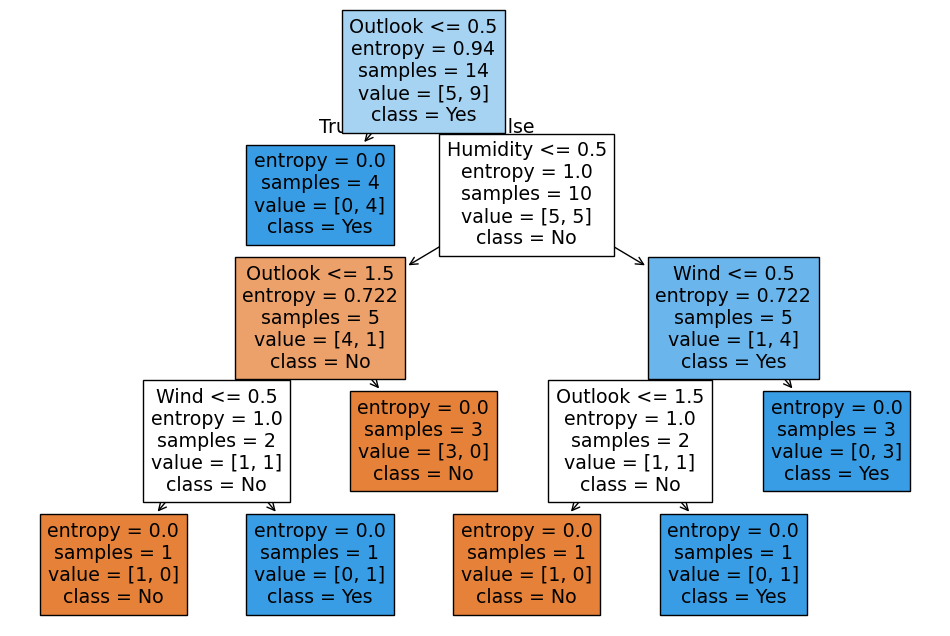

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
tree.plot_tree(clf, feature_names=['Outlook', 'Temp', 'Humidity', 'Wind'], class_names=['No', 'Yes'], filled=True)
plt.show()

### Step 5: Make a Prediction
We predict for a new day: **Sunny, Cool, Normal Humidity, Strong Wind**.
Note: We must manually map these words to the codes used above. 
*   **Outlook**: Sunny=2 (assuming alphabetical: Overcast=0, Rain=1, Sunny=2)
*   **Temp**: Cool=0
*   **Humidity**: Normal=1
*   **Wind**: Strong=0

*(Note: In a real app, you would save the Encoders to do this mapping automatically)*.

In [12]:
# Example vector [Outlook=2(Sunny), Temp=0(Cool), Humidity=1(Normal), Wind=0(Strong)]
# Please verify codes from data_encoded printout if strictly following alphabetical.

testVec = [[2, 0, 1, 0]] 
predict_val = clf.predict(testVec)
print(f"Prediction: {predict_val} (1=Yes, 0=No)")

Prediction: [1] (1=Yes, 0=No)


C:\Users\carlos\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
